In [23]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [25]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])  #input features
y = insurance_data["charges"]  #output feature

X = pd.get_dummies(X, columns= ["region"], drop_first=True, dtype=int) # creates 4 columns for 4 region classes, assigns 1 or 0 for each data 

#Encoding/mapping
X["sex"] = X["sex"].map({"female":1, "male":0})
X["smoker"] = X["smoker"].map({"yes":1, "no":0})

X["age_smoker"] = X["sex"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


MSE for alpha=0.001: 20967434.46794832
MSE for alpha=0.1: 20966651.13896849
MSE for alpha=1: 20959779.893194612
MSE for alpha=2: 20952681.27798844
MSE for alpha=5: 20934693.754589017
MSE for alpha=10: 20915910.440451186
MSE for alpha=20: 20919087.627840236
MSE for alpha=30: 20974782.721781965
MSE for alpha=40: 21078211.100978
MSE for alpha=50: 21227740.54876919
MSE for alpha=100: 22442023.492578287


<Axes: >

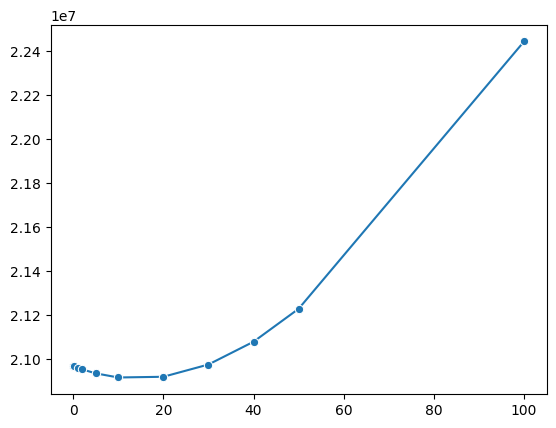

In [29]:
import seaborn as sns

# lasso regression
alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas: 
    lasso_model = linear_model.Lasso(alpha = a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha={a}:", mse)
    mses.append(mse)

# figure out which alpha is optimal, closest to x axis. from the line plot, we see the optimal alpha should be in range(10,20)
sns.lineplot(x=alphas, y=mses, marker = "o")

In [30]:
# LassoCV - cross validation
from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5, # how many cross validation folds
    max_iter=1000,
    random_state=42 
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha:", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE =", mse)
print("r2 =", r2)

best alpha: 5.0
MSE = 20934693.754589017
r2 = 0.8651538498676987
